# Part 13: Preference Alignment — From "follows instructions" to "follows preferences"

In notebook 12 we used **SFT** to make a base model follow instructions. But SFT only
teaches the model to imitate *one* demonstrated answer. It cannot express that, among
several valid answers, humans **prefer** some over others — more helpful, more honest,
more polite, safer.

That gap is what **preference alignment** closes, and it is the stage that turns a
capable model into a genuinely useful, well-behaved assistant (it's the "RLHF" in
ChatGPT and the "RL" in Claude's training). This notebook builds the two dominant
approaches from scratch:

1. A **reward model** trained on human preference comparisons (Bradley–Terry).
2. **RLHF / PPO** — the classic pipeline (we explain the mechanics conceptually).
3. **DPO** (Direct Preference Optimization) — a simpler method that skips the reward
   model and the RL loop, which we implement and train end-to-end.

As in notebook 12, we use the repo's `src/` GPT on a tiny toy task so everything runs on
CPU in a couple of minutes. The point is the *mechanism*.

In [1]:
import sys, time, copy
sys.path.append('..')
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.gpt import GPT
from src.train import CharTokenizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)
print('device:', device)

device: cpu


## Step 1: Preference data

The raw material of alignment is not "correct answers" — it is **comparisons**. A human
(or another model) is shown two responses to the same prompt and picks the better one,
giving a triple **(prompt, chosen, rejected)**.

For our toy task the preference rule is simple and explicit: a *polite, complete*
response is **chosen** over a *curt* one. This stands in for real human preferences like
"more helpful" — a consistent, learnable signal.

In [2]:
PROMPT_TMPL = "### Instruction:\n{instr}\n### Response:\n"
END = "\x03"; PAD = "\x00"
names = ["Alice", "Bob", "Cara", "Dan", "Eve"]

# (instruction, chosen=polite, rejected=curt)
prefs = []
for n in names:
    prefs.append((f"greet {n}", f"Hello, {n}! Nice to meet you.", f"hi {n}"))
    prefs.append((f"thank {n}", f"Thank you, {n}, for your help.", f"thanks"))
    prefs.append((f"help {n}",  f"Of course, {n}, I am happy to help!", f"no"))

train_prefs, held_prefs = prefs[:12], prefs[12:]   # hold out a few for evaluation
print(f"{len(prefs)} preference pairs ({len(train_prefs)} train / {len(held_prefs)} held-out)")
i, c, r = prefs[0]
print(f"\nprompt   : {i!r}\nchosen   : {c!r}\nrejected : {r!r}")

15 preference pairs (12 train / 3 held-out)

prompt   : 'greet Alice'
chosen   : 'Hello, Alice! Nice to meet you.'
rejected : 'hi Alice'


In [3]:
# Tokenizer over the union of pretraining text + all preference strings.
with open('../data/sample_text.txt', 'r', encoding='utf-8') as f:
    pretrain_text = f.read()
allstr = ([PROMPT_TMPL.format(instr=i) + c + END for i, c, r in prefs] +
          [PROMPT_TMPL.format(instr=i) + r + END for i, c, r in prefs])
tokenizer = CharTokenizer(pretrain_text + PAD + END + "".join(allstr))
PAD_ID = tokenizer.encode(PAD)[0]
END_ID = tokenizer.encode(END)[0]

def new_model():
    return GPT(vocab_size=tokenizer.vocab_size, d_model=128, num_heads=4,
               num_layers=3, max_seq_len=128, dropout=0.0).to(device)

def enc_full(instr, resp):
    return tokenizer.encode(PROMPT_TMPL.format(instr=instr) + resp + END)
print('vocab size:', tokenizer.vocab_size)

vocab size: 65


## Step 2: The reward model

A **reward model** $r_\phi(\text{prompt}, \text{response})$ outputs a single scalar: how
good is this response? We build it from a transformer backbone (the same architecture as
our GPT) with the language-model head replaced by a **scalar head** that reads the final
token's hidden state.

We can't train it with labeled scores — humans don't give numbers, they give
*comparisons*. So we use the **Bradley–Terry** model: the probability that the chosen
response beats the rejected one is $\sigma(r_\phi(\text{chosen}) - r_\phi(\text{rejected}))$.
Maximizing that likelihood gives the loss:

$$ \mathcal{L}_{RM} = -\,\mathbb{E}_{(x,\,y_w,\,y_l)}\big[\log \sigma\big(r_\phi(x, y_w) - r_\phi(x, y_l)\big)\big] $$

where $y_w$ is the winner (chosen) and $y_l$ the loser (rejected). The model only ever
learns *relative* preferences — exactly the signal humans provide.

In [4]:
class RewardModel(nn.Module):
    # Transformer backbone + scalar head over the last real token.
    def __init__(self, gpt):
        super().__init__()
        self.embedding = gpt.embedding
        self.decoder = gpt.decoder
        self.head = nn.Linear(gpt.d_model, 1)

    def forward(self, ids, lengths):
        x = self.embedding(ids)
        x, _ = self.decoder(x)
        last = x[torch.arange(x.size(0)), lengths - 1]   # hidden state at last real token
        return self.head(last).squeeze(-1)               # scalar reward per sequence

def batchify(seqs):
    L = max(len(s) for s in seqs)
    lengths = torch.tensor([len(s) for s in seqs], device=device)
    ids = torch.tensor([s + [PAD_ID] * (L - len(s)) for s in seqs], device=device)
    return ids, lengths

In [5]:
def train_reward(rm, data, steps=300, lr=5e-4):
    cid, cl = batchify([enc_full(i, c) for i, c, r in data])
    rid, rl = batchify([enc_full(i, r) for i, c, r in data])
    opt = torch.optim.AdamW(rm.parameters(), lr=lr); rm.train()
    losses = []; t0 = time.time()
    for s in range(steps):
        loss = -F.logsigmoid(rm(cid, cl) - rm(rid, rl)).mean()   # Bradley-Terry
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(rm.parameters(), 1.0); opt.step()
        losses.append(loss.item())
    print(f"reward model trained in {time.time()-t0:.1f}s, final loss {losses[-1]:.3f}")
    return losses

@torch.no_grad()
def reward_margin(rm, data):
    rm.eval()
    cid, cl = batchify([enc_full(i, c) for i, c, r in data])
    rid, rl = batchify([enc_full(i, r) for i, c, r in data])
    sc, sr = rm(cid, cl), rm(rid, rl)
    return (sc - sr).mean().item(), (sc > sr).float().mean().item()

reward_model = RewardModel(new_model())
rm_losses = train_reward(reward_model, train_prefs, steps=300)

margin, acc = reward_margin(reward_model, held_prefs)
print(f"held-out: mean reward(chosen) - reward(rejected) = {margin:.2f}, "
      f"chosen-preferred {acc:.0%} of the time")
assert acc >= 0.8, "reward model did not learn the preference"
print("PASS: the reward model generalizes the preference to unseen prompts.")

reward model trained in 9.5s, final loss 0.000
held-out: mean reward(chosen) - reward(rejected) = 12.87, chosen-preferred 100% of the time
PASS: the reward model generalizes the preference to unseen prompts.


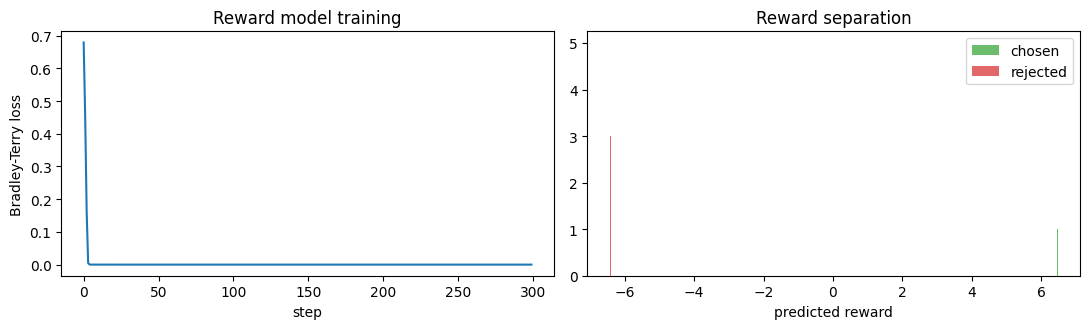

In [6]:
# Visualize: the reward model pushes chosen and rejected scores apart.
rm_eval = reward_model
with torch.no_grad():
    rm_eval.eval()
    cid, cl = batchify([enc_full(i, c) for i, c, r in prefs])
    rid, rl = batchify([enc_full(i, r) for i, c, r in prefs])
    sc = rm_eval(cid, cl).cpu().numpy(); sr = rm_eval(rid, rl).cpu().numpy()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(rm_losses); a1.set_xlabel('step'); a1.set_ylabel('Bradley-Terry loss')
a1.set_title('Reward model training')
a2.hist(sc, bins=12, alpha=0.7, label='chosen', color='#2ca02c')
a2.hist(sr, bins=12, alpha=0.7, label='rejected', color='#d62728')
a2.set_xlabel('predicted reward'); a2.set_title('Reward separation'); a2.legend()
plt.tight_layout(); plt.show()

## Step 3: RLHF / PPO — the concept

With a reward model in hand, classic **RLHF** optimizes the language model (the *policy*
$\pi_\theta$) to maximize reward, using the **PPO** reinforcement-learning algorithm:

```
repeat:
    1. sample responses from the current policy:      y ~ π_θ(· | x)
    2. score them with the frozen reward model:       r = r_φ(x, y)
    3. update π_θ to increase reward — but penalize    objective:
       drifting too far from the SFT reference π_ref:    E[ r_φ(x,y) − β · KL(π_θ ‖ π_ref) ]
```

The **KL penalty** is essential: without it the policy "reward-hacks," collapsing onto
whatever degenerate text the reward model happens to over-score. The $\beta$ term keeps
it close to the sensible SFT model.

RLHF works extremely well but is **operationally heavy**: you train and serve a separate
reward model, sample on-policy during training, and juggle four models at once
(policy, reference, reward, and a value/critic network). It is also notoriously sensitive
to hyperparameters. This complexity is exactly what the next method removes.

## Step 4: DPO — skip the reward model

**Direct Preference Optimization** comes from a clean observation: the policy that
maximizes the KL-penalized RLHF objective has a *closed form*, and you can rearrange it so
the reward is expressed directly in terms of the policy's own log-probabilities. Substitute
that back into the Bradley–Terry loss and the reward model **cancels out entirely**.

What's left is a simple supervised loss on preference pairs — no reward model, no
sampling, no RL:

$$ \mathcal{L}_{DPO} = -\log \sigma\!\Big(\beta\Big[\big(\log\pi_\theta(y_w|x) - \log\pi_{ref}(y_w|x)\big) - \big(\log\pi_\theta(y_l|x) - \log\pi_{ref}(y_l|x)\big)\Big]\Big) $$

In words: **raise** the policy's log-probability of the chosen response and **lower** it
for the rejected one — each measured *relative to a frozen reference model* (the SFT
model), with $\beta$ controlling how far the policy may move. The bracketed term is an
*implicit* reward; DPO is RLHF's objective in disguise, optimized directly.

In [7]:
# First we need a reference policy: an SFT model fluent in the response format.
# We SFT briefly on BOTH chosen and rejected responses (a realistic RLHF starting point),
# then DPO will shift probability mass toward the chosen ones.
def sft_pairs(model, data, steps=300, lr=5e-4):
    seqs = []
    for i, c, r in data:
        for resp in (c, r):
            ids = enc_full(i, resp)
            plen = len(tokenizer.encode(PROMPT_TMPL.format(instr=i)))
            seqs.append((ids, plen))
    L = max(len(ids) for ids, _ in seqs)
    X, Y = [], []
    for ids, plen in seqs:
        ids2 = ids + [PAD_ID] * (L - len(ids))
        y = [(-1 if (j + 1 < plen or ids2[j + 1] == PAD_ID) else ids2[j + 1])
             for j in range(len(ids2) - 1)]
        X.append(ids2[:-1]); Y.append(y)
    X = torch.tensor(X, device=device); Y = torch.tensor(Y, device=device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr); model.train(); t0 = time.time()
    for s in range(steps):
        _, loss = model(X, Y); opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    print(f"reference SFT trained in {time.time()-t0:.1f}s, final loss {loss.item():.3f}")

policy = new_model()
sft_pairs(policy, train_prefs, steps=300)
reference = copy.deepcopy(policy)             # frozen reference π_ref
for p in reference.parameters():
    p.requires_grad_(False)
reference.eval()

reference SFT trained in 9.5s, final loss 0.054


GPT(
  (embedding): TransformerEmbedding(
    (token_embedding): TokenEmbedding(
      (embedding): Embedding(65, 128)
    )
    (position_encoding): LearnablePositionalEncoding(
      (dropout): Dropout(p=0.0, inplace=False)
      (position_embedding): Embedding(128, 128)
    )
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-2): 3 x DecoderBlock(
        (attention): CausalSelfAttention(
          (attention): MultiHeadAttention(
            (W_q): Linear(in_features=128, out_features=128, bias=False)
            (W_k): Linear(in_features=128, out_features=128, bias=False)
            (W_v): Linear(in_features=128, out_features=128, bias=False)
            (W_o): Linear(in_features=128, out_features=128, bias=False)
            (attention): ScaledDotProductAttention(
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
        )
        (ffn): FeedForward(
          (linear1): Linear(in_features=128, out_features=512, bias=True)
    

In [8]:
def seq_logprob(model, instr, resp):
    # Sum of log-probabilities of the RESPONSE tokens (prompt masked out).
    ids = torch.tensor([enc_full(instr, resp)], device=device)
    plen = len(tokenizer.encode(PROMPT_TMPL.format(instr=instr)))
    logits, _ = model(ids)
    logp = F.log_softmax(logits, dim=-1)
    tgt = ids[0, 1:]
    lp = logp[0, :-1].gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
    mask = torch.arange(1, ids.size(1), device=device) >= plen   # response positions
    return (lp * mask).sum()

@torch.no_grad()
def logprob_margin(model, data):
    # Mean over pairs of [ logπ(chosen) - logπ(rejected) ].
    return torch.stack([seq_logprob(model, i, c) - seq_logprob(model, i, r)
                        for i, c, r in data]).mean().item()

In [9]:
# DPO training loop.
BETA = 0.1
margins = [logprob_margin(policy, train_prefs)]
opt = torch.optim.AdamW(policy.parameters(), lr=2e-4); policy.train(); t0 = time.time()
for step in range(150):
    loss = 0.0
    for i, c, r in train_prefs:
        lp_c = seq_logprob(policy, i, c); lp_r = seq_logprob(policy, i, r)
        with torch.no_grad():
            rp_c = seq_logprob(reference, i, c); rp_r = seq_logprob(reference, i, r)
        loss = loss - F.logsigmoid(BETA * ((lp_c - rp_c) - (lp_r - rp_r)))
    loss = loss / len(train_prefs)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
    margins.append(logprob_margin(policy, train_prefs))
print(f"DPO trained in {time.time()-t0:.1f}s, final loss {loss.item():.3f}")
print(f"logπ(chosen) - logπ(rejected):  before {margins[0]:.2f}  ->  after {margins[-1]:.2f}")
assert margins[-1] > margins[0], "DPO did not increase the preference margin"
print("PASS: the policy now assigns relatively higher probability to the chosen responses.")

DPO trained in 23.8s, final loss 0.007
logπ(chosen) - logπ(rejected):  before -0.49  ->  after 56.98
PASS: the policy now assigns relatively higher probability to the chosen responses.


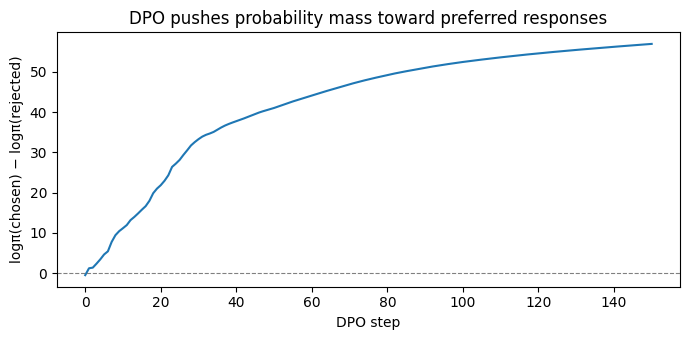

In [10]:
plt.figure(figsize=(7, 3.5))
plt.plot(margins, color='#1f77b4')
plt.axhline(0, color='gray', lw=0.8, ls='--')
plt.xlabel('DPO step'); plt.ylabel('logπ(chosen) − logπ(rejected)')
plt.title('DPO pushes probability mass toward preferred responses')
plt.tight_layout(); plt.show()

## Step 5: The full post-training picture

Putting notebooks 12 and 13 together, here is how a modern assistant is actually made:

| Stage | Objective | Data | Turns a model into... |
|---|---|---|---|
| **Pretraining** (nb 01–09) | Next-token prediction | Trillions of tokens of raw text | a fluent base model |
| **SFT** (nb 12) | Masked next-token loss | (instruction, response) demos | an instruction-follower |
| **Reward model** (this nb) | Bradley–Terry on comparisons | (prompt, chosen, rejected) | a scorer of human preference |
| **RLHF / PPO** | Max reward − β·KL | reward model + on-policy samples | a preference-aligned policy |
| **DPO** | Direct preference loss | (prompt, chosen, rejected) | the same, without the RL machinery |

**When to use which:** DPO is simpler, stable, and cheap — it's the common default for
open models. RLHF/PPO is more complex but supports *online* signals (a live reward model,
tool feedback, on-policy exploration) and remains widely used in frontier labs, often in
combination with newer variants.

## Summary

### Key Takeaways
- **Alignment optimizes preferences, not demonstrations.** SFT imitates one answer;
  alignment learns *which* answer humans prefer, from **comparisons**.
- **Reward models learn from comparisons, not scores.** The Bradley–Terry loss
  $-\log\sigma(r_w - r_l)$ turns "A is better than B" into a trainable scalar reward.
- **RLHF maximizes reward under a KL leash.** The $\beta\,\mathrm{KL}(\pi_\theta\|\pi_{ref})$
  penalty prevents reward-hacking — but the full PPO pipeline is heavy (four models,
  on-policy sampling).
- **DPO is RLHF's objective in disguise.** A closed-form derivation makes the reward
  model cancel, leaving a simple supervised loss that raises chosen / lowers rejected
  log-probs relative to a frozen reference. No reward model, no sampling, no RL loop.
- This is the final stage of the journey: **pretrain → SFT → align**. The same
  transformer and the same gradient descent, all the way through.

### Where to go next
- **RLAIF / Constitutional AI** — use an AI, guided by a written constitution, to generate
  the preference labels instead of humans.
- **Online / iterative DPO** — regenerate preference pairs from the improving policy and
  repeat, recovering some of RLHF's on-policy benefits.
- **Evaluation** — alignment makes "better" subjective; measuring it (win-rates,
  LLM-as-judge, red-teaming) is its own discipline.

### References
- [InstructGPT — Ouyang et al., 2022](https://arxiv.org/abs/2203.02155) — the RLHF pipeline
- [PPO — Schulman et al., 2017](https://arxiv.org/abs/1707.06347) — the RL algorithm behind RLHF
- [DPO — Rafailov et al., 2023](https://arxiv.org/abs/2305.18290) — direct preference optimization
- [Constitutional AI — Bai et al., 2022](https://arxiv.org/abs/2212.08073) — RLAIF / harmlessness

You've now built the entire modern LLM stack from scratch — from a single attention head
in notebook 03 to a preference-aligned assistant here. 🎓